# Block 2: Season Weighting for Bayesian MARCEL (wRC+)

Joint fit of Block 1 (hierarchical pooling) + Block 2 (two-season Beta weighting).
Adds a two-year weighted projection and a prediction likelihood.

Target years: 2018–2023. Input-only years: 2016 and 2017.

The three-season variant (Dirichlet weighting, target years 2019–2023) is archived
in `archive/` along with its fitted trace.

In [47]:
import sys
sys.path.insert(0, '../../../src')

import importlib
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

import models.marcel
importlib.reload(models.marcel)

from models.marcel import (
    load_and_filter,
    run_sanity_checks,
    build_prediction_table,
    run_prediction_sanity_checks,
    build_block2_model,
    fit_block2,
    run_block2_diagnostics,
)

## 1. Load and validate data

In [48]:
df = load_and_filter('../../../data/fg_builds/fg_hitters_train.csv')
run_sanity_checks(df)
print(f"\nBlock 1 table: {len(df)} rows, {df['IDfg'].nunique()} players")

 IDfg              Name  Season  PA  wRC+
 7002 Will Middlebrooks    2016  31  -2.0
14128        Joey Gallo    2016  30  -3.0
13051   Chris Colabello    2016  32 -37.0
 5485       Jose Pirela    2016  41  -2.0
 2917  Emmanuel Burriss    2016  50  -4.0
 2833     Cedric Hunter    2016  36 -21.0
11902    Hanser Alberto    2016  58 -37.0
 3211   Tyler Ladendorf    2016  50 -59.0
 2677    Jordan Pacheco    2016  51  -8.0
 4403        Erik Kratz    2016  87 -41.0
 2852     Chris Marrero    2017  41  -2.0
13877        Alex Mejia    2017  49 -18.0
 5277   Tuffy Gosewisch    2017  31 -59.0
10953     Phil Gosselin    2017  50  -8.0
 4054  Emilio Bonifacio    2017  44 -18.0
14876         Jacob May    2017  42 -41.0
 2539        Pete Kozma    2017  51  -5.0
11905   Orlando Calixte    2017  55  -8.0
11241      Mike Freeman    2017  66  -7.0
11997        Cody Asche    2017  62 -12.0
15450     Daniel Castro    2018  47  -4.0
15181      Ryan Cordell    2018  40 -17.0
15274     Mike Tauchman    2018  3

In [49]:
pred_df = build_prediction_table(df)
run_prediction_sanity_checks(pred_df)
print(f"\nPrediction table: {len(pred_df)} rows")
print(f"n_prior distribution:\n{pred_df['n_prior'].value_counts().sort_index()}")

Prediction table checks passed. 2705 rows, n_prior distribution: {1: 647, 2: 2058}

Prediction table: 2705 rows
n_prior distribution:
n_prior
1     647
2    2058
Name: count, dtype: int64


## 2. Build joint model

In [50]:
model = build_block2_model(df, pred_df)

In [51]:
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print(f"Skipping model graph (graphviz not installed): {e}")

Skipping model graph (graphviz not installed): This function requires the python library graphviz, along with binaries. The easiest way to install all of this is by running

	conda install -c conda-forge python-graphviz


## 3. Sample posterior

Starting with tune=2000, draws=1000, target_accept=0.95.

In [52]:
trace = fit_block2(model)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_theta, sigma_theta, sigma_obs, theta_raw, w]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 21 seconds.
Sampling: [wrc_plus, wrc_pred]


## 4. Diagnostics

Block 1 posterior means for shift comparison:

Max R-hat: 1.0076 — PASS
Divergences: 0

Posterior summary (hyper-parameters):
                mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_theta      95.929  0.449   95.081   96.771      0.011    0.008    1600.0   
sigma_theta   19.730  0.438   18.963   20.594      0.015    0.010     887.0   
sigma_obs    380.309  4.468  372.322  389.138      0.121    0.085    1361.0   

             ess_tail  r_hat  
mu_theta       2494.0   1.00  
sigma_theta    2153.0   1.01  
sigma_obs      1963.0   1.00  

Posterior summary (weight on t-1):
    mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
w  0.605  0.05   0.512      0.7      0.002    0.001     661.0    1293.0    1.0

Posterior means: w[t-1]=0.605, w[t-2]=0.395

Shift from Block 1 posteriors:
  mu_theta: 0.71
  sigma_theta: 0.67
  sigma_obs: 7.11 *** FLAG

ESS for w: 661


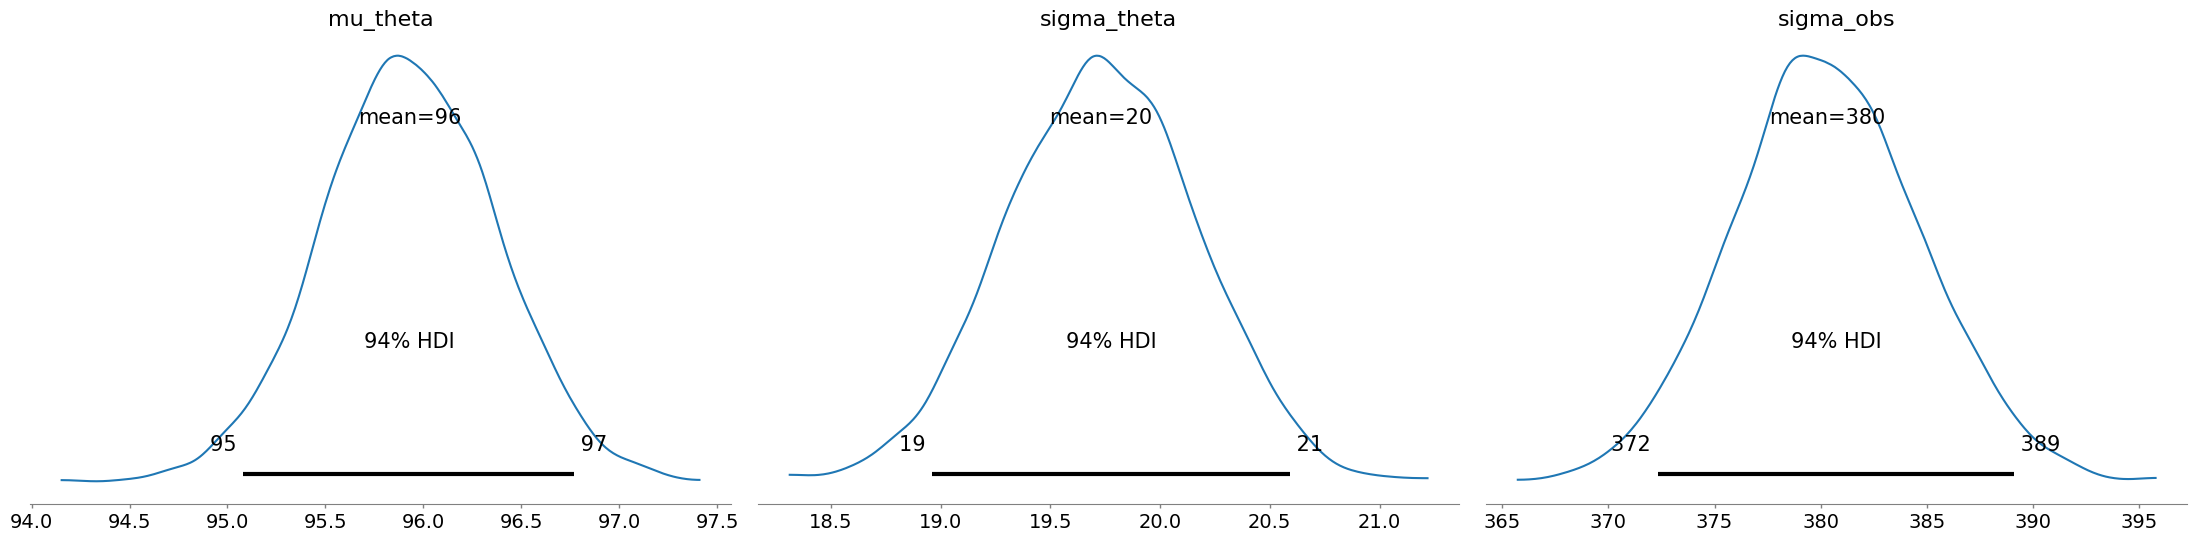

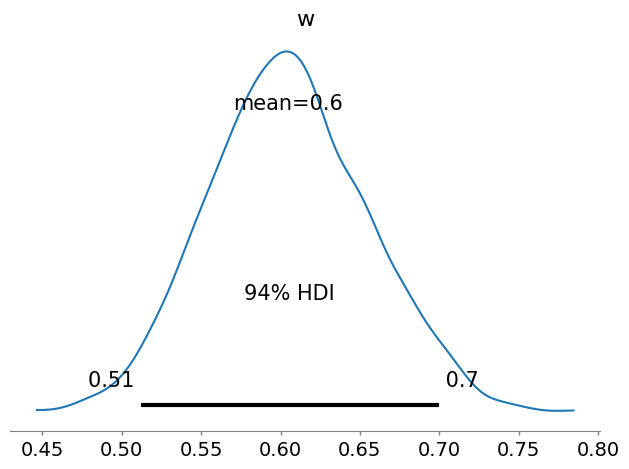

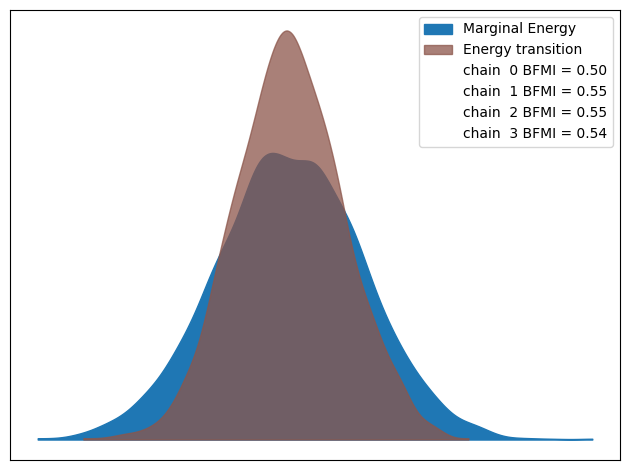

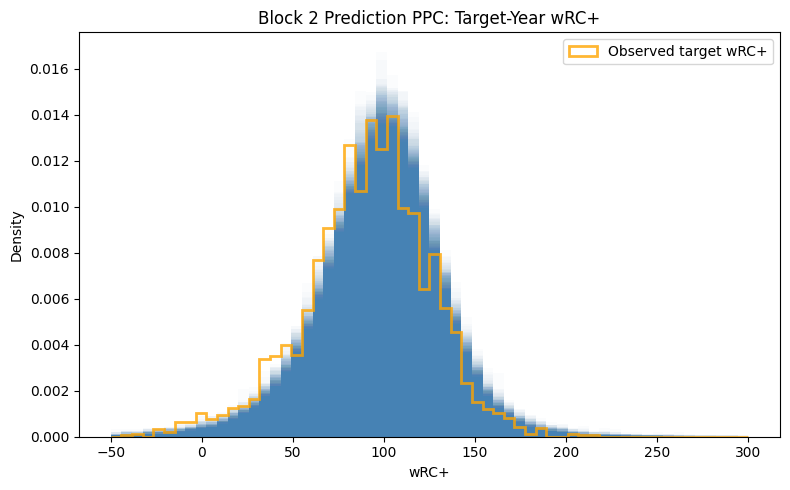

In [53]:
# Block 1 reference values (from Block 1 fit)
block1_ref = {
    "mu_theta": 96.64,
    "sigma_theta": 19.06,
    "sigma_obs": 373.2,
}

results = run_block2_diagnostics(trace, pred_df, block1_summary=block1_ref, output_dir='.')

## 5. Save trace

In [54]:
import pickle

with open('block2_trace.pkl', 'wb') as f:
    pickle.dump(trace, f)
print('Trace saved to notebooks/models/block2/block2_trace.pkl')

Trace saved to notebooks/models/block2/block2_trace.pkl


## 6. Inspect a single player-season projection

Fill in `player_name` and `season` to see the posterior predictive distribution
for that player's projected wRC+ in the target season.

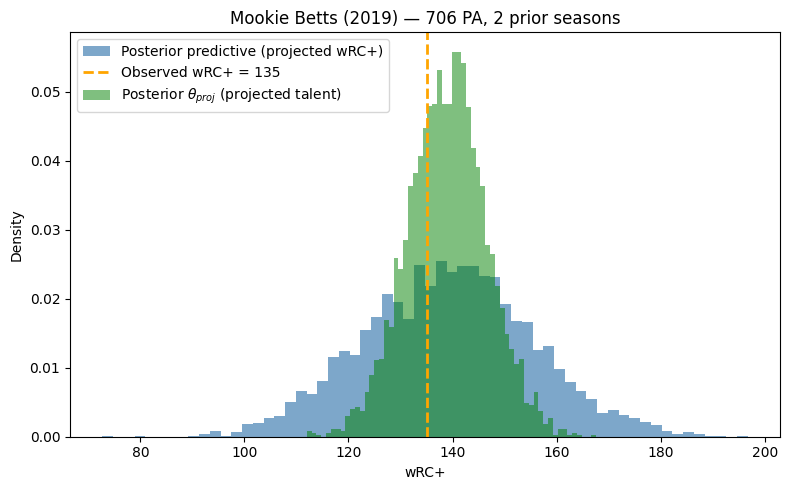

In [55]:
# ---- Fill these in ----
player_name = "Mookie Betts"
season      = 2019        # must be in 2018–2023
# ------------------------

matches = pred_df[pred_df["Name"] == player_name]
if matches.empty:
    raise ValueError(f"No player named '{player_name}' found in prediction table")
unique_ids = matches["IDfg"].unique()
if len(unique_ids) > 1:
    raise ValueError(
        f"'{player_name}' maps to multiple player IDs: {unique_ids.tolist()}. "
        "Use IDfg directly to disambiguate."
    )

row = matches[matches["Season"] == season]
if row.empty:
    available = sorted(matches["Season"].unique())
    raise ValueError(f"'{player_name}' has no projection for {season}. Available: {available}")

key = row["pred_key"].values[0]
obs_wrc = row["wRC+"].values[0]
obs_pa = row["PA"].values[0]
n_prior = row["n_prior"].values[0]

ppc_draws = trace.posterior_predictive["wrc_pred"].sel(pred_row=key).values.flatten()
theta_proj_draws = trace.posterior["theta_proj"].sel(pred_row=key).values.flatten()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ppc_draws, bins=60, density=True, alpha=0.7, color="steelblue",
        label="Posterior predictive (projected wRC+)")
ax.axvline(obs_wrc, color="orange", linewidth=2, linestyle="--",
           label=f"Observed wRC+ = {obs_wrc:.0f}")
ax.hist(theta_proj_draws, bins=60, density=True, alpha=0.5, color="green",
        label=r"Posterior $\theta_{proj}$ (projected talent)")

ax.set_xlabel("wRC+")
ax.set_ylabel("Density")
ax.set_title(f"{player_name} ({season}) — {obs_pa} PA, {n_prior} prior seasons")
ax.legend()
plt.tight_layout()
plt.show()